# Exploratory Data Analysis

## Project Goal

We are building a churn prediction project that should lead to:

- an ML model that predicts churn probability
- feature importance to explain why churn happens
- business targeting logic for customer retention
- a Streamlit app that returns churn probability, risk level, and action recommendation

This EDA notebook focuses on understanding the data, identifying the strongest churn drivers, and translating those findings into actionable business insights.

In [1]:
import math
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/cleaned_train.csv")
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [3]:
overview = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "missing_values": [int(df.isna().sum().sum())],
    "duplicate_rows": [int(df.duplicated().sum())],
    "churn_rate_pct": [round(df["Churn"].mean() * 100, 2)]
})

overview

,rows,columns,missing_values,duplicate_rows,churn_rate_pct
0,594194,21,0,0,22.52




This cell gives a quick health check of the cleaned training data: total rows, number of columns, missing values, duplicates, and overall churn rate.

outcome

The dataset has **594,194 rows**, **21 columns**, **0 missing values**, and **0 duplicate rows**. The churn rate is about **22.52%**. This tells us the target is not perfectly balanced, which matters for model evaluation later.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 1. Target Variable Analysis

Since churn prediction is the final business problem, we start by understanding the target variable first.

Total customers: 594194


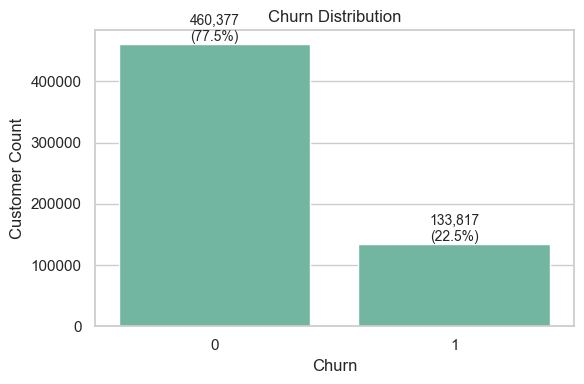

Churn
0    77.48
1    22.52
Name: percentage, dtype: float64

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")

total = len(df)
print(f"Total customers: {total}")

for patch in ax.patches:
    count = int(patch.get_height())
    pct = count / total * 100
    ax.annotate(
        f"{count:,}\n({pct:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

df["Churn"].value_counts(normalize=True).mul(100).round(2).rename("percentage")



This cell visualizes the target distribution and also prints the class percentages.

### Outcome and effect

Most customers are non-churners, while about **22.5%** churn. This means the problem has moderate class imbalance. In the modeling stage, accuracy alone will not be enough, and we should pay attention to metrics like recall, precision, F1-score, and ROC-AUC.

## 2. Univariate Analysis



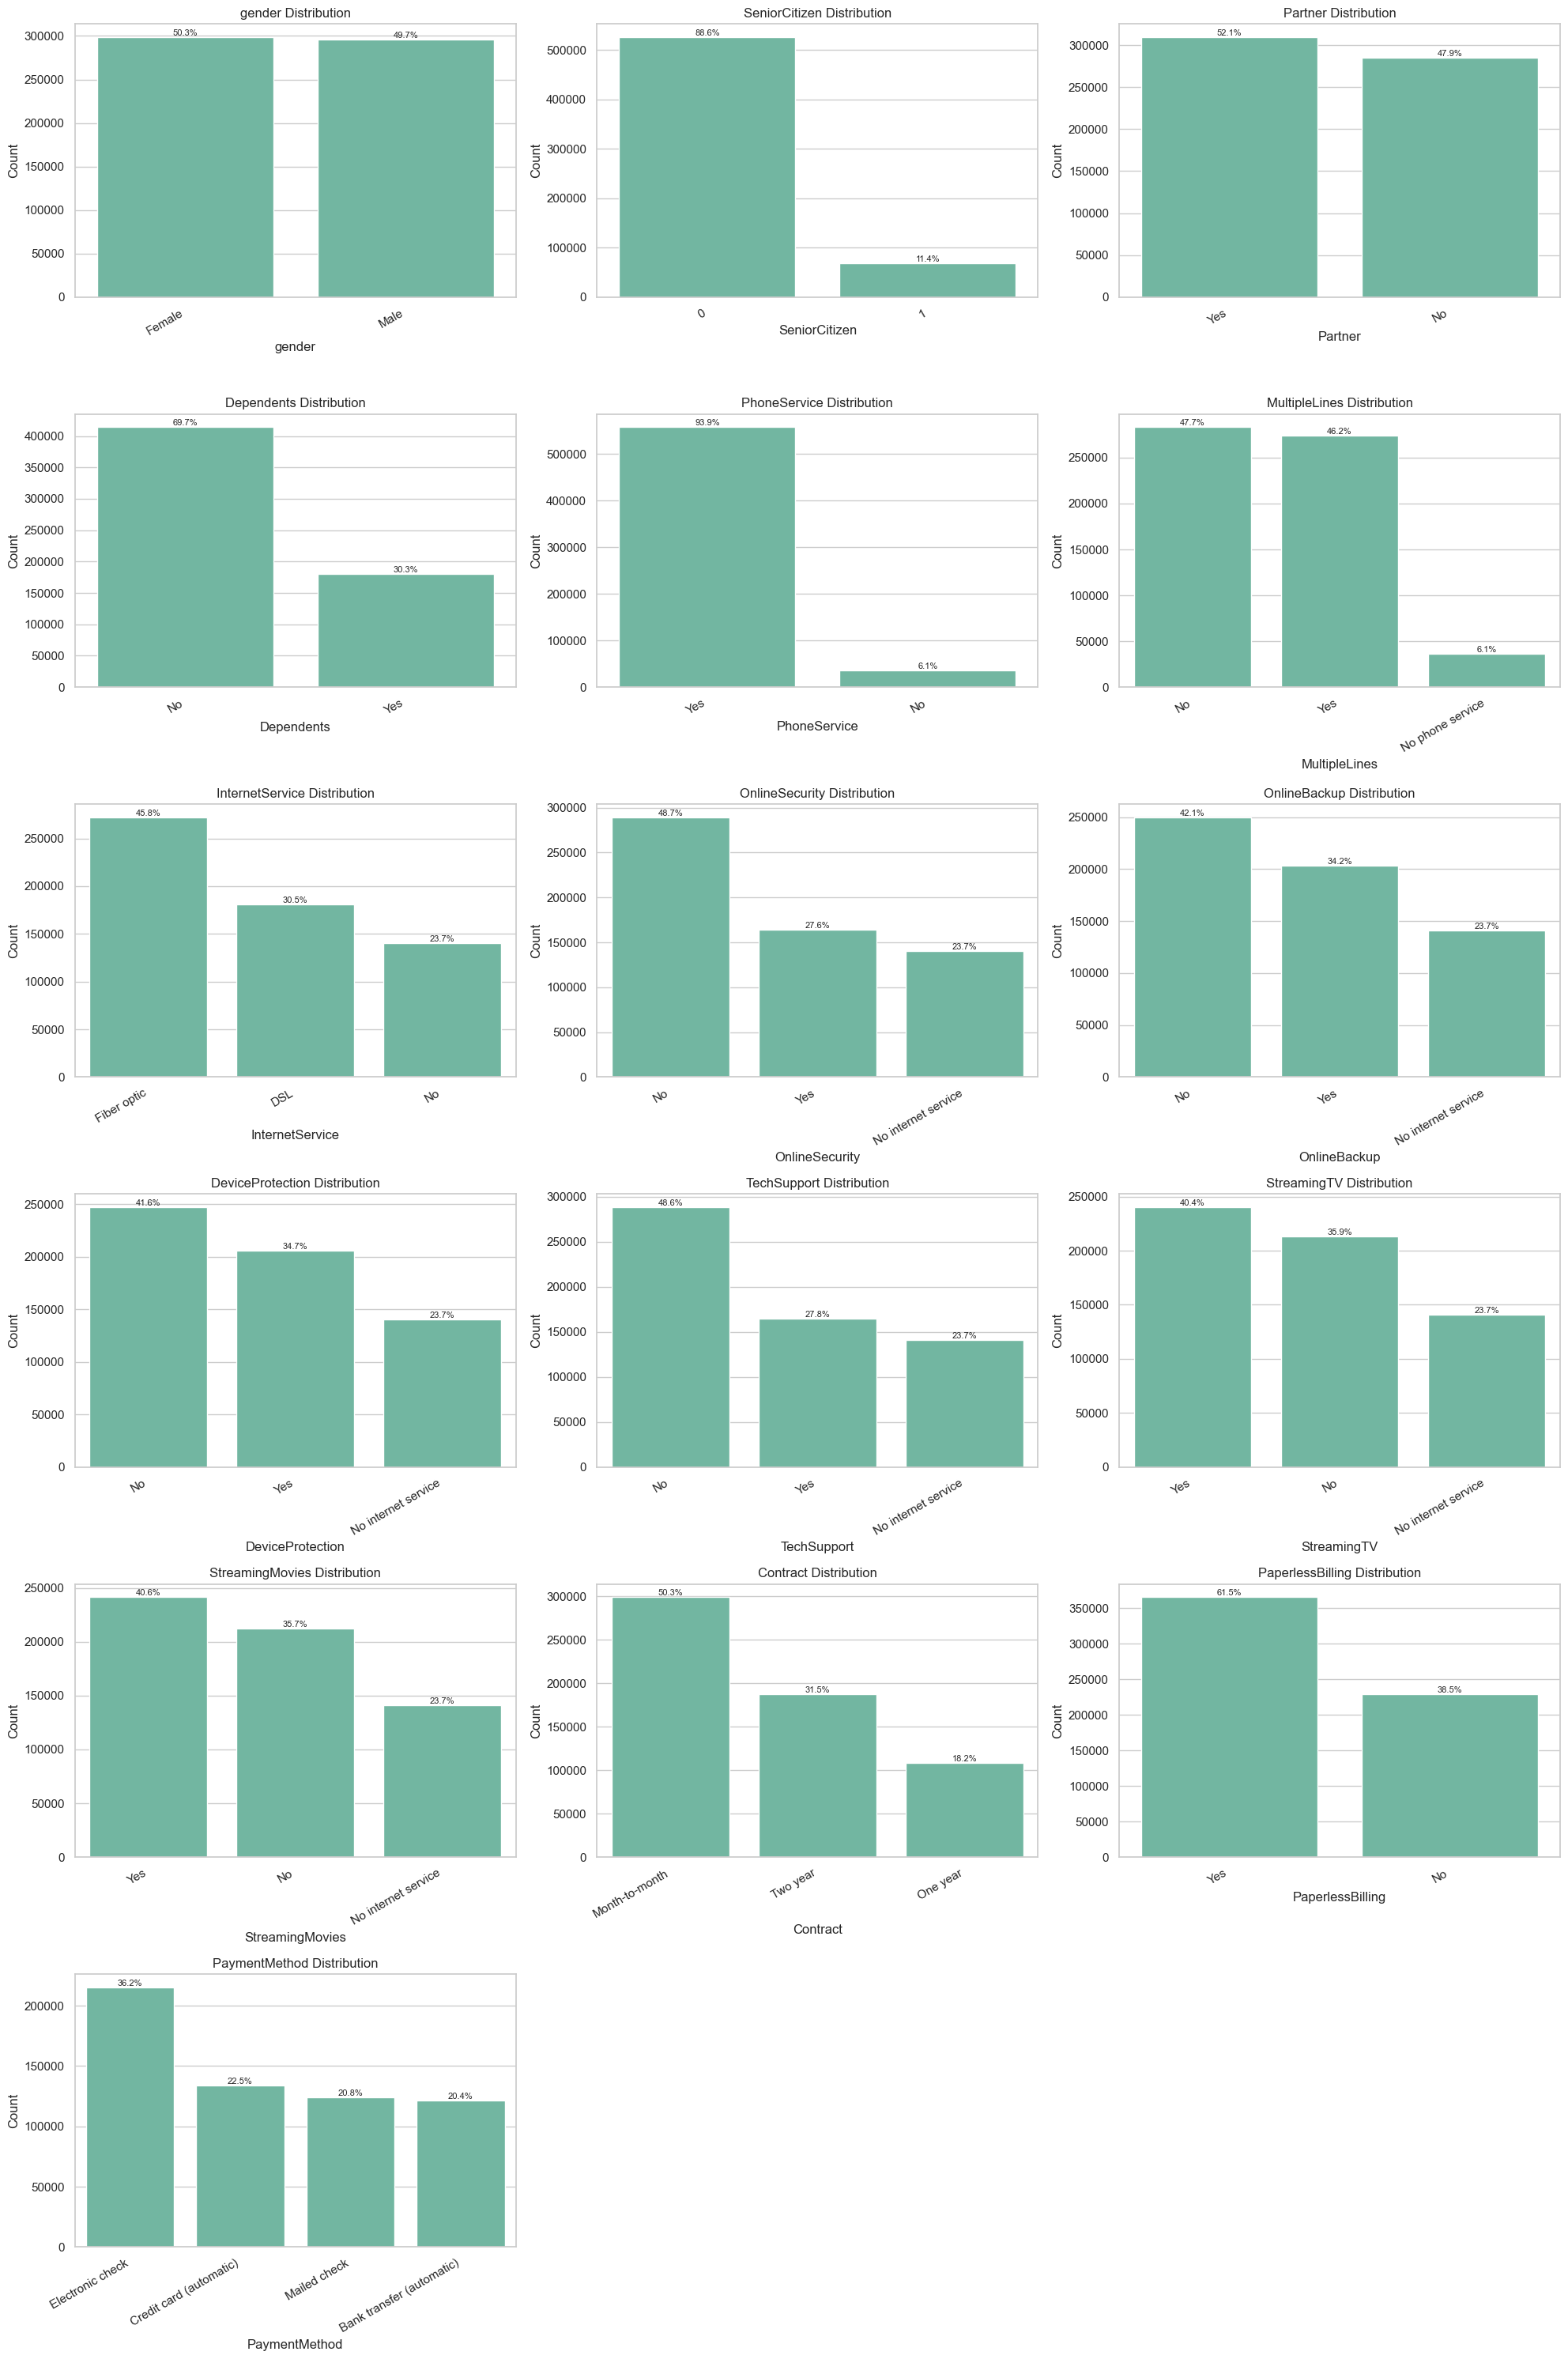

In [6]:
cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")

    total = len(df)
    for patch in ax.patches:
        count = int(patch.get_height())
        pct = count / total * 100
        ax.annotate(
            f"{pct:.1f}%",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()



This cell draws all the categorical feature distributions in one grid using a loop.

### Outcome and effect

This helps us understand the customer mix. A reviewer can quickly see which categories dominate the dataset, such as common contract types, internet service choices, and payment preferences. This makes the notebook cleaner and more professional.

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


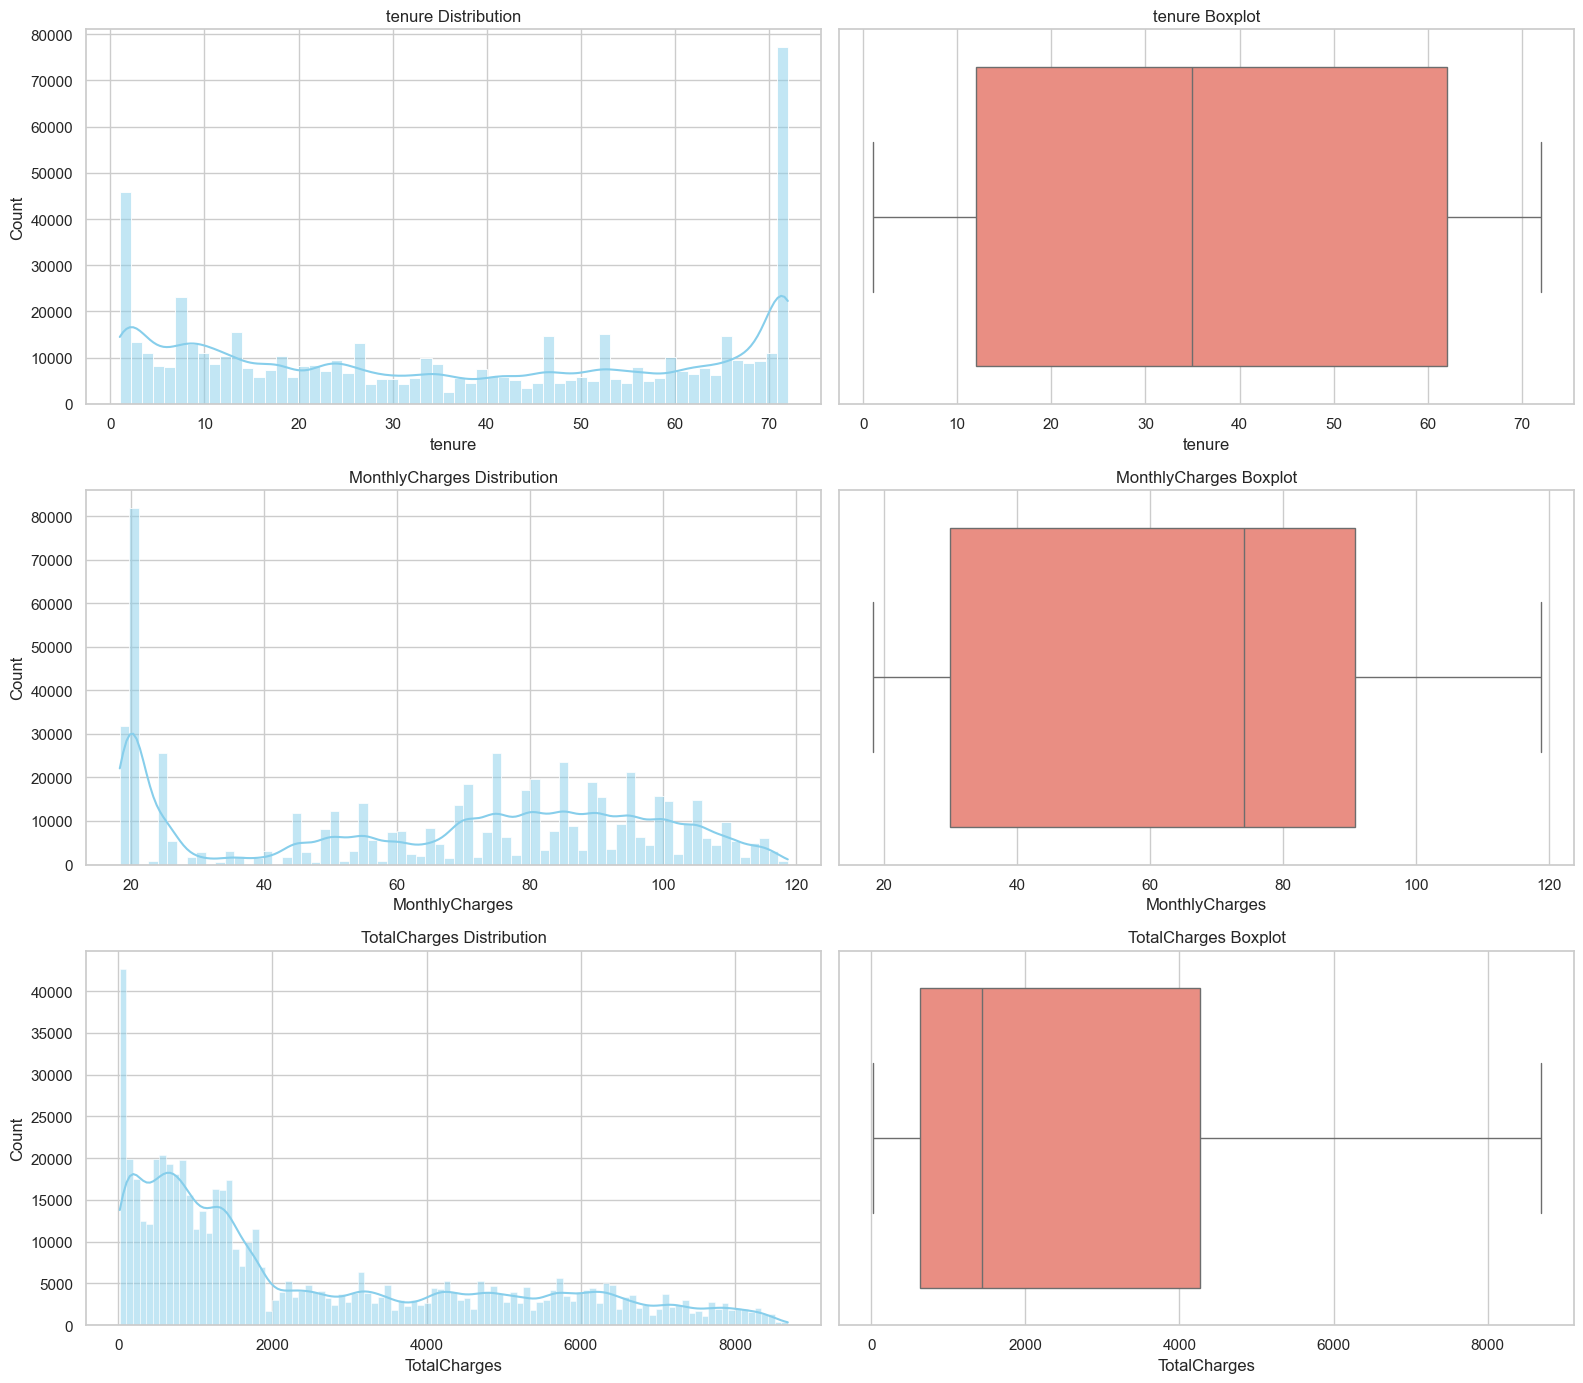

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"{col} Distribution")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="salmon")
    axes[i, 1].set_title(f"{col} Boxplot")

plt.tight_layout()
plt.show()



shows summary statistics for the main numeric variables. The second cell shows their distributions and outlier patterns.

### Outcome and effect

These plots help us understand customer tenure, pricing spread, and total spend. This matters because churn is often closely related to how long a customer has stayed and how expensive their plan is.

## 3. Bivariate Analysis With Churn

This is the most important part of the EDA because it directly connects customer characteristics to churn behavior.

In [9]:
def churn_rate_table(column_name):
    table = (
        df.groupby(column_name)["Churn"]
        .agg(churn_rate="mean", customer_count="size")
        .sort_values("churn_rate", ascending=False)
        .reset_index()
    )
    table["churn_rate"] = (table["churn_rate"] * 100).round(2)
    return table

important_cat_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "PaperlessBilling",
    "Partner", "Dependents", "SeniorCitizen"
]

for col in important_cat_cols:
    print(f"\n{col} churn summary")
    display(churn_rate_table(col))


Contract churn summary


,Contract,churn_rate,customer_count
0,Month-to-month,42.05,298918
1,One year,5.76,108333
2,Two year,1.00,186943



InternetService churn summary


,InternetService,churn_rate,customer_count
0,Fiber optic,41.54,272386
1,DSL,10.31,181081
2,No,1.43,140727



PaymentMethod churn summary


...

,Partner,churn_rate,customer_count
0,No,32.46,284640
1,Yes,13.38,309554



Dependents churn summary


,Dependents,churn_rate,customer_count
0,No,29.14,414362
1,Yes,7.28,179832



SeniorCitizen churn summary


,SeniorCitizen,churn_rate,customer_count
0,1,50.03,67799
1,0,18.98,526395


### What this cell does

This cell creates a reusable churn-rate summary table and applies it to the most important categorical features.

### Outcome and effect

This is where the strongest churn drivers start becoming obvious:

- **Month-to-month** customers churn far more than one-year or two-year customers.
- **Fiber optic** users churn much more than DSL or no-internet customers.
- **Electronic check** customers have the highest churn among payment methods.
- Customers without **OnlineSecurity** or **TechSupport** churn much more.
- **Senior citizens**, customers without **partners**, and customers without **dependents** also churn more.

These findings directly support later feature importance and business targeting logic.

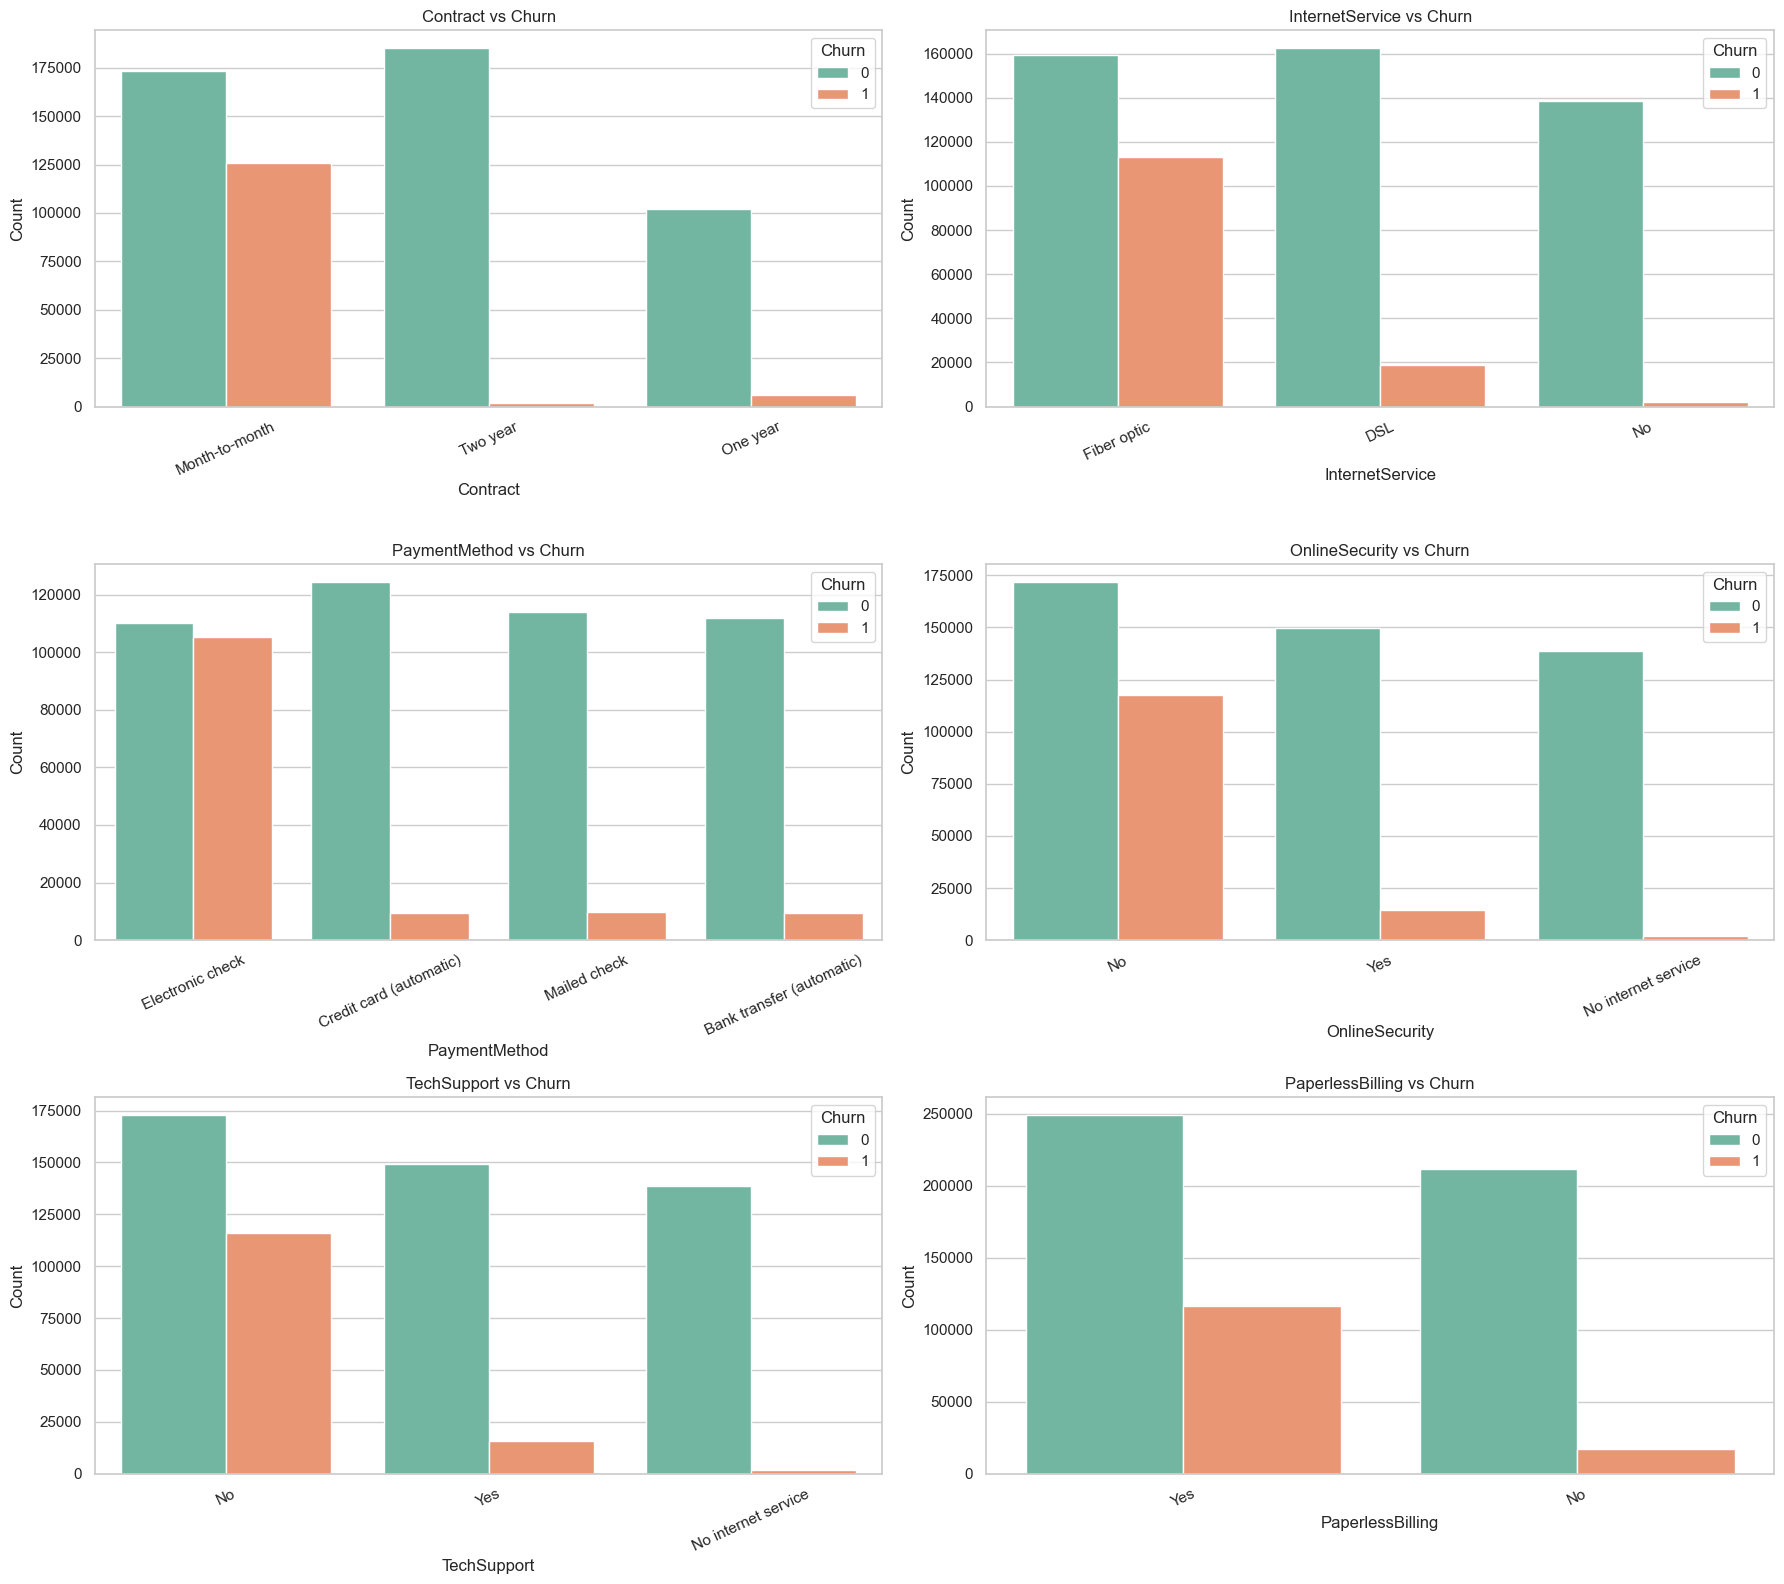

In [10]:
key_features = [
    "Contract", "InternetService", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "PaperlessBilling"
]

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.countplot(data=df, x=col, hue="Churn", order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

for ax in axes[len(key_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### What this cell does

This cell compares churn and non-churn counts side by side for the strongest categorical churn drivers.

### Outcome and effect

These plots make the differences visually obvious. They are especially useful in interviews or portfolio reviews because they communicate churn behavior fast without needing the reviewer to read long tables.

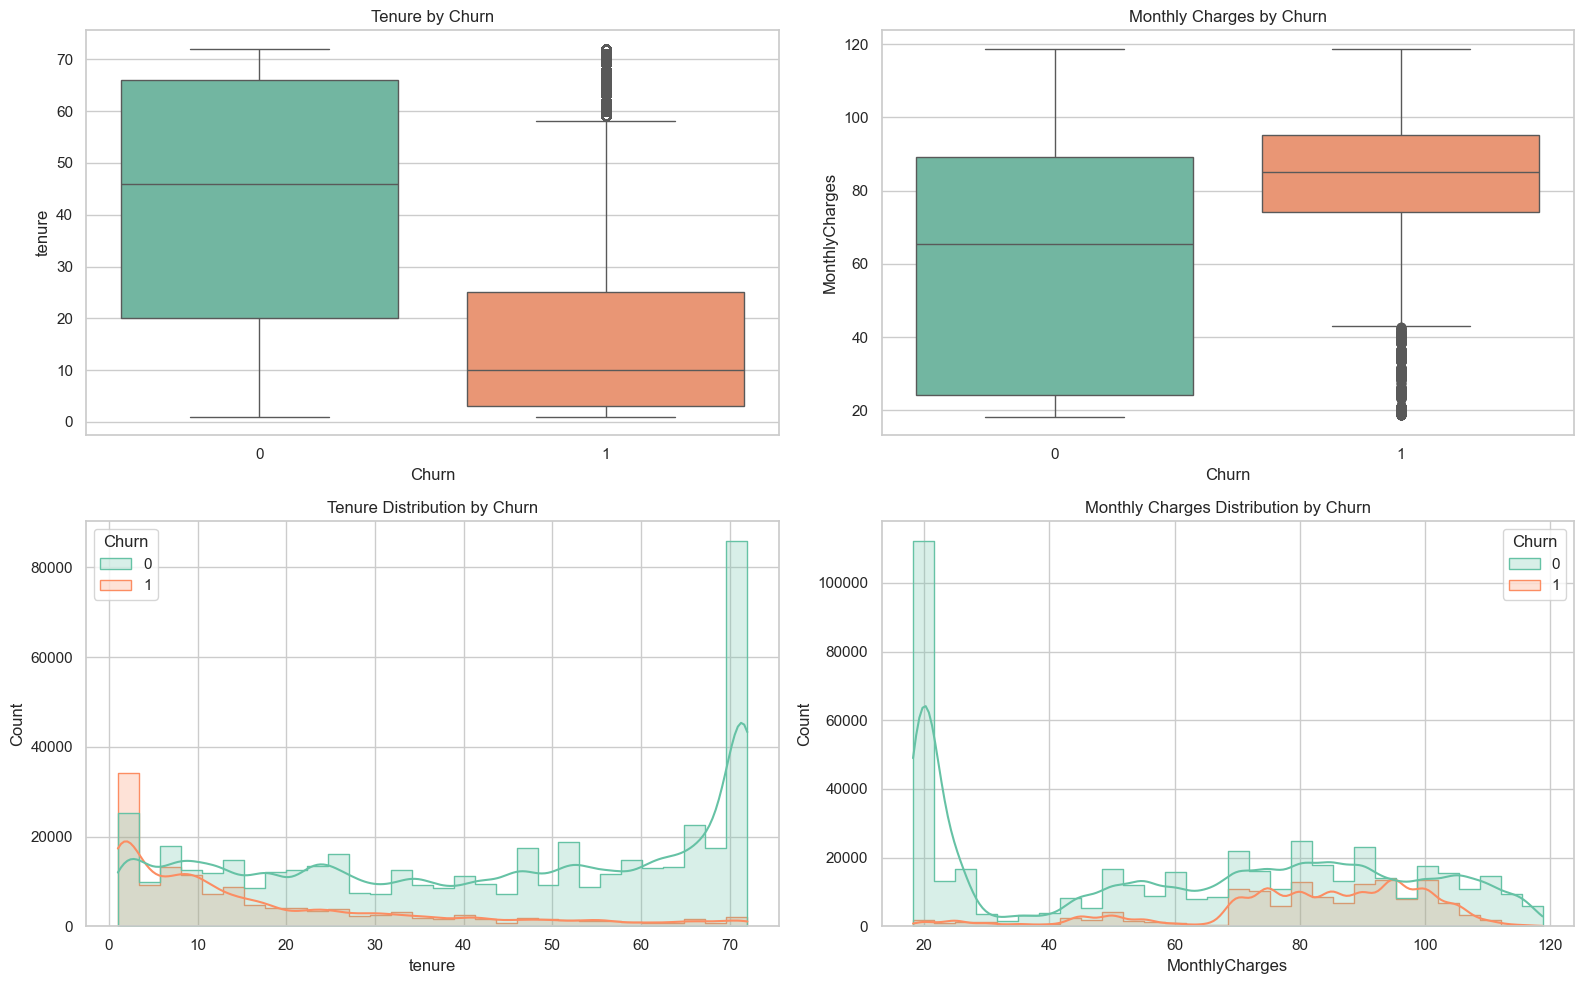

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Tenure by Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Monthly Charges by Churn")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[1, 0], element="step")
axes[1, 0].set_title("Tenure Distribution by Churn")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True, ax=axes[1, 1], element="step")
axes[1, 1].set_title("Monthly Charges Distribution by Churn")

plt.tight_layout()
plt.show()

### What this cell does

This cell compares numeric behavior between churners and non-churners.

### Outcome and effect

Two strong patterns usually stand out:

- churners tend to have **lower tenure**, meaning newer customers are much more fragile
- churners tend to have **higher monthly charges**, meaning price pressure is likely a churn factor

This is important because it helps us later define customer risk levels in the app.

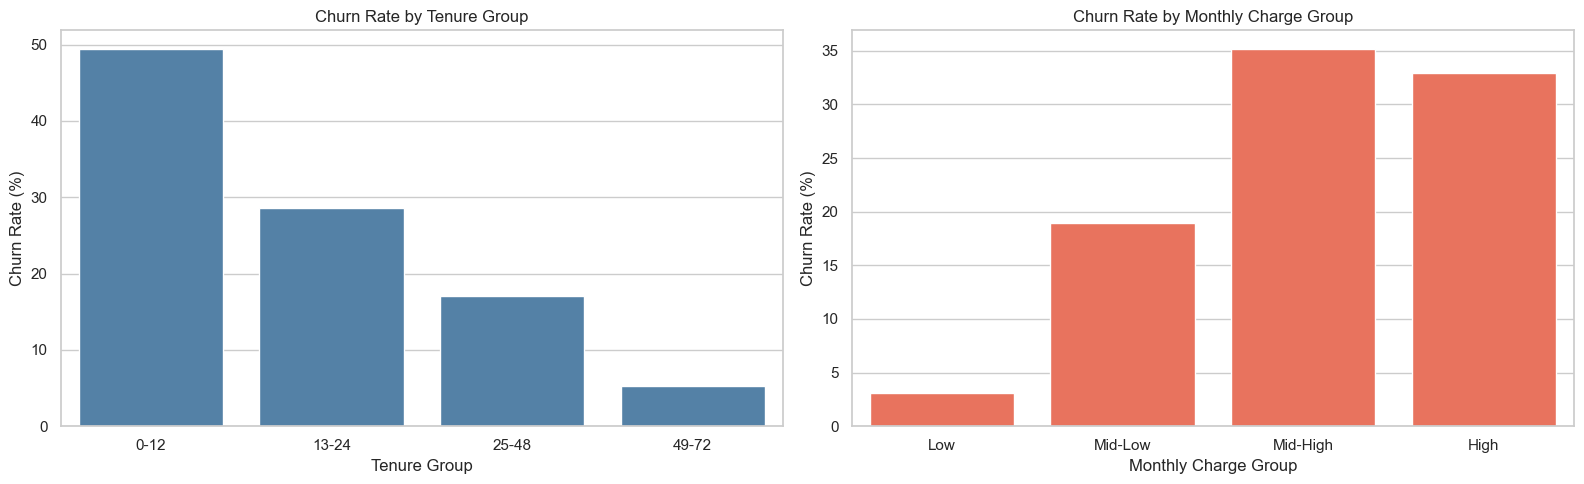

,tenure_group,churn_rate_pct
0,0-12,49.39
1,13-24,28.58
2,25-48,17.07
3,49-72,5.27


,monthly_charge_group,churn_rate_pct
0,Low,3.06
1,Mid-Low,18.92
2,Mid-High,35.15
3,High,32.96


In [12]:
df["tenure_group"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"])
df["monthly_charge_group"] = pd.qcut(df["MonthlyCharges"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

tenure_churn = (
    df.groupby("tenure_group", observed=False)["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="churn_rate_pct")
)

monthly_churn = (
    df.groupby("monthly_charge_group", observed=False)["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="churn_rate_pct")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=tenure_churn, x="tenure_group", y="churn_rate_pct", ax=axes[0], color="steelblue")
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_xlabel("Tenure Group")
axes[0].set_ylabel("Churn Rate (%)")

sns.barplot(data=monthly_churn, x="monthly_charge_group", y="churn_rate_pct", ax=axes[1], color="tomato")
axes[1].set_title("Churn Rate by Monthly Charge Group")
axes[1].set_xlabel("Monthly Charge Group")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

display(tenure_churn)
display(monthly_churn)

### What this cell does

This cell groups continuous variables into business-friendly buckets and then measures churn rate within each bucket.

### Outcome and effect

The results are very useful for decision-making:

- customers with **0-12 months** tenure have the highest churn, around **49.39%**
- churn decreases sharply as tenure increases, reaching about **5.27%** for long-tenure customers
- customers in higher monthly-charge groups churn much more than low-charge customers

This helps us define business rules like: *new and expensive-plan customers should be contacted first*.

## 4. Correlation Analysis

This section checks the relationships among numeric features and their connection with churn.

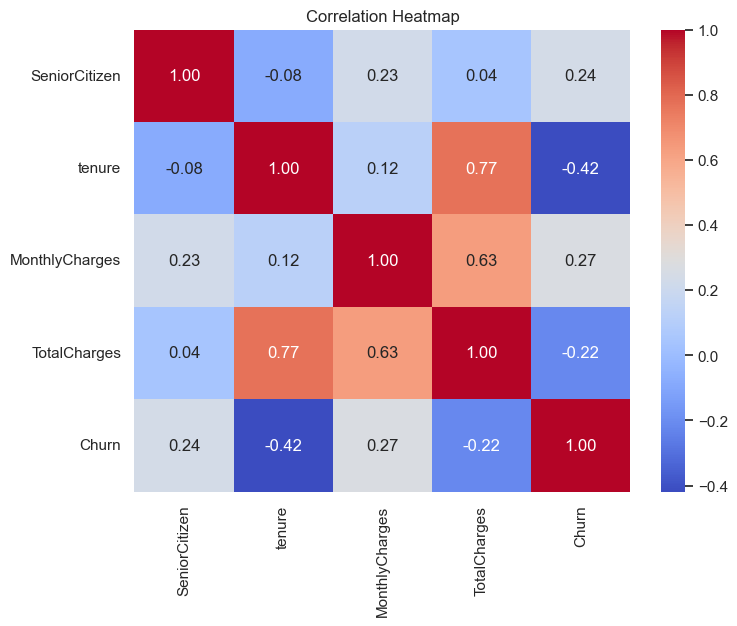

,Churn
Churn,1.000000
MonthlyCharges,0.272997
SeniorCitizen,0.236362
TotalCharges,-0.218365
tenure,-0.418453


In [13]:
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr_matrix[["Churn"]].sort_values("Churn", ascending=False)

### What this cell does

This cell creates a correlation matrix for the numeric columns and highlights how each one relates to churn.

### Outcome and effect

The strongest numeric signal is **tenure**, which is negatively correlated with churn. **MonthlyCharges** and **SeniorCitizen** show positive relationships with churn, while **TotalCharges** is negatively related. These relationships support what we observed visually and make these variables strong candidates for the model.

## 5. Business-Focused Risk Segments

This section converts EDA findings into business-ready targeting ideas.

In [14]:
segment_summary = (
    df.groupby(["Contract", "InternetService", "PaymentMethod"])["Churn"]
    .agg(churn_rate="mean", customer_count="size")
    .query("customer_count >= 5000")
    .sort_values("churn_rate", ascending=False)
    .reset_index()
)
segment_summary["churn_rate"] = (segment_summary["churn_rate"] * 100).round(2)
segment_summary.head(10)

,Contract,InternetService,PaymentMethod,churn_rate,customer_count
0,Month-to-month,Fiber optic,Electronic check,61.23,148153
1,Month-to-month,Fiber optic,Mailed check,42.97,9515
2,Month-to-month,DSL,Electronic check,33.09,31564
3,Month-to-month,Fiber optic,Bank transfer (automatic),32.93,18624
4,Month-to-month,Fiber optic,Credit card (automatic),32.57,17606
5,One year,Fiber optic,Electronic check,18.65,16108
6,Month-to-month,DSL,Mailed check,17.66,25345
7,Month-to-month,DSL,Credit card (automatic),13.10,10957
8,Month-to-month,DSL,Bank transfer (automatic),12.05,9866
9,One year,Fiber optic,Bank transfer (automatic),9.62,10123


### What this cell does

This cell finds high-risk customer segments by combining contract type, internet service type, and payment method.

### Outcome and effect

One of the clearest high-risk groups is:

- **Month-to-month + Fiber optic + Electronic check** customers, with churn above **60%**

This is exactly the kind of pattern we need for the business-targeting part of the project and for action recommendations in the app.

## 6. Key Insights and Their Business Effects

### Main EDA findings

1. **Contract type is a major churn driver.** Month-to-month customers churn much more than one-year and two-year customers.
2. **Tenure is one of the strongest predictors.** New customers are much more likely to churn than long-tenure customers.
3. **Monthly charges matter.** Higher charge groups show much higher churn rates.
4. **Support and security services reduce churn.** Customers without online security or tech support are much more likely to leave.
5. **Fiber optic customers have elevated churn.** This may reflect pricing pressure or service expectations.
6. **Electronic check is a warning sign.** This payment method consistently shows the highest churn.
7. **Paperless billing, senior-citizen status, no partner, and no dependents** are also associated with higher churn.

### Why these insights matter for the final project

- They tell us which features are likely to become important in the churn model.
- They help us explain model predictions in business language.
- They give us a first draft of the action logic for the Streamlit app.
- They show HR or recruiters that the project is not only technical but also business-aware.

## 7. Next Step After EDA

The next notebook should be the modeling notebook. In that file we should:

- encode categorical variables properly
- split train and validation sets
- train churn prediction models
- compare metrics
- extract feature importance
- define risk bands and action recommendations for the app